# Unidad 4 — Notebook 1: Árboles de Decisión

**Materia:** Métodos de Análisis de Datos 1 (MAD1)  
**Departamento de Matemática — Universidad Nacional del Sur (UNS)**  
**Nombre:**  
**Fecha:**

---

## Glosario de siglas

| Sigla | Significado |
|-------|-------------|
| CART | Classification and Regression Trees (Árboles de Clasificación y Regresión) |
| CV | Cross-Validation (Validación Cruzada) |
| ML | Machine Learning (Aprendizaje Automático) |
| AP | Aprendizaje Supervisado |

---

## Objetivos

- Calcular manualmente los criterios de impureza **Gini** y **Entropía** para evaluar splits.
- Implementar y ajustar árboles de decisión usando `scikit-learn`.
- Analizar el efecto de la profundidad máxima sobre el sobreajuste.

---

## Parte 1 — Cálculo a mano: Gini y Entropía

Considerá el siguiente dataset de 8 pacientes. La variable respuesta es `Enfermedad` (Sí/No). Queremos evaluar si conviene hacer el split en la variable `Glucosa > 120`.

| Paciente | Glucosa | Enfermedad |
|----------|---------|------------|
| 1        | 95      | No         |
| 2        | 110     | No         |
| 3        | 130     | Sí         |
| 4        | 145     | Sí         |
| 5        | 105     | No         |
| 6        | 160     | Sí         |
| 7        | 115     | No         |
| 8        | 140     | Sí         |

El split propuesto divide en:
- **Nodo izquierdo** (Glucosa ≤ 120): pacientes 1, 2, 5, 7
- **Nodo derecho** (Glucosa > 120): pacientes 3, 4, 6, 8

### 1.1 Impureza de Gini

Recordá que para un nodo con clases $k = 1, \ldots, K$:

$$\text{Gini}(t) = 1 - \sum_{k=1}^{K} p_k^2$$

donde $p_k$ es la proporción de observaciones de clase $k$ en el nodo $t$.

La impureza ponderada del split es:

$$\text{Gini}_{\text{split}} = \frac{n_L}{n} \cdot \text{Gini}(t_L) + \frac{n_R}{n} \cdot \text{Gini}(t_R)$$

**Ejercicio 1.1.a** — Calculá la impureza de Gini para el nodo raíz (antes del split, los 8 pacientes juntos).

*Espacio para desarrollo:*

Tenemos dos clases, k=1,2.

Siendo la clase k=1 los no enfermos y k=2 los enfermos, $p_1=\frac{4}{8}=\frac{1}{2}$ y $p_2=\frac{4}{8}=\frac{1}{2}$

Luego, siguiendo la fórmula proporcionada, nos queda que $\text{Gini}(t)=\frac{1}{2}$

**Ejercicio 1.1.b** — Calculá Gini para el nodo izquierdo y para el nodo derecho por separado.

>Para el nodo izquierdo, con glucosa<120:

Tenemos a los pacientes 1, 2, 5 y 7. Observamos que todos son pacientes sanos. Lo que implica que $p_1=1$ y $p_2=0$.

Luego, $\text{Gini}(t_L)=1-1=0$

>Para el nodo derecho, con glucosa>120

Tenemos a los paciente 3, 4, 6 y 8. Observamos que todos son pacientes enfermos. Lo que implica que que $p_1=0$ y $p_2=1$

Luego,  $\text{Gini}(t_R)=1-1=0$

**Ejercicio 1.1.c** — Calculá la impureza ponderada del split. ¿Hubo ganancia respecto al nodo raíz?

En este caso, $n=8$ y $n_1=n_2=4$. Con lo calculado antes tenemos:
$$\text{Gini}_\text{split}=\frac{4}{8}(0)+\frac{4}{8}(0)=0$$
Notemos que estamos en el caso ideal, en el que $\text{Gini}_\text{split}=0$, lo que indica que los dos hijos quedaron puros. Así que sí, hubo ganancia de 0,5. 

### 1.2 Entropía e Información Ganada

La impureza por **Entropía** de Shannon para un nodo $t$ es:

$$H(t) = -\sum_{k=1}^{K} p_k \log_2(p_k)$$

La **Ganancia de Información** (Information Gain) del split es:

$$IG = H(\text{raíz}) - \left( \frac{n_L}{n} \cdot H(t_L) + \frac{n_R}{n} \cdot H(t_R) \right)$$

> **Convención:** si $p_k = 0$, el término $0 \cdot \log_2(0) = 0$.

**Ejercicio 1.2.a** — Calculá la Entropía del nodo raíz, del nodo izquierdo y del nodo derecho.

>Para el nodo raíz:

Tenemos que $p_1=4$ y $p_2=4$. Luego,

$$
H(t)=-
\left(
\frac{4}{8}\log_{2}\left(\frac{4}{8}\right)
+
\frac{4}{8}\log_{2}\left(\frac{4}{8}\right)
\right)=-
\left(
\frac{1}{2}\log_{2}\left(\frac{1}{2}\right)
+
\frac{1}{2}\log_{2}\left(\frac{1}{2}\right)
\right)=-\log_{2}\left(\frac{1}{2}\right)=-(-1)=1

$$

>Para el nodo izquierdo:

Tenemos que $p_1=4$ y $p_2=0$. Luego,
$$
H(t_L)=-
\left(
\frac{4}{4}\log_{2}\left(\frac{4}{4}\right)+
\frac{0}{4}\log_{2}\left(\frac{0}{4}\right)
\right)
=
-
\left(
\log_{2}(1)+
0\log_{2}(0)
\right)=0
$$

>Para el nodo derecho:

Tenemos que $p_1=0$ y $p_2=4$. Luego,
$$
H(t_R)=-
\left(
\frac{0}{4}\log_{2}\left(\frac{0}{4}\right)+
\frac{4}{4}\log_{2}\left(\frac{4}{4}\right)
\right)
=
-
\left(
0\log_{2}(0)+
\log_{2}(1)
\right)=0
$$

**Ejercicio 1.2.b** — Calculá la Ganancia de Información del split.

$$IG=1-\left(\frac{4}{8}(0)+\frac{4}{8}(0)\right)=1-(0+0)=1$$

**Ejercicio 1.2.c** — ¿Ambos criterios (Gini y Entropía) concuerdan en que este split es bueno? ¿Qué diferencias conceptuales tienen?

Ambos criterios concuerdan en que el split es muy bueno. De hecho, ambos concuerdan en que es el mejor pues la Ganancia de Información en la Entropía es el máximo y la impureza del split calculada con Gini es 0. 

La diferencia está en que Gini mide la probabilidad de equivocarse si clasificamos al azar según las proporciones del nodo y la Entropía mide el desorden de los datos. Computacionalmente, Gini es más eficiente pues no requiere logaritmos.

---

## Parte 2 — Verificación computacional

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score

# Dataset del ejercicio a mano
glucosa = np.array([95, 110, 130, 145, 105, 160, 115, 140])
enfermedad = np.array([0, 0, 1, 1, 0, 1, 0, 1])  # 0=No, 1=Sí
X_manual = glucosa.reshape(-1, 1)
y_manual = enfermedad

**Ejercicio 2.1** — Completá el código para entrenar un árbol con criterio Gini y otro con Entropía, ambos con profundidad máxima 1 (un solo split).

In [2]:
# Árbol con criterio Gini
arbol_gini = DecisionTreeClassifier(
    criterion= 'gini',        # TU CÓDIGO ACÁ
    max_depth=1 ,        # TU CÓDIGO ACÁ
    random_state=42
)
arbol_gini.fit(X_manual, y_manual)  # TU CÓDIGO ACÁ

# Árbol con criterio Entropía
arbol_entropia = DecisionTreeClassifier(
    criterion= 'entropy',        # TU CÓDIGO ACÁ
    max_depth=1,        # TU CÓDIGO ACÁ
    random_state=42
)
arbol_entropia.fit(X_manual, y_manual)  # TU CÓDIGO ACÁ

print("Árbol Gini:")
print(export_text(arbol_gini, feature_names=['Glucosa']))
print("\nÁrbol Entropía:")
print(export_text(arbol_entropia, feature_names=['Glucosa']))

Árbol Gini:
|--- Glucosa <= 122.50
|   |--- class: 0
|--- Glucosa >  122.50
|   |--- class: 1


Árbol Entropía:
|--- Glucosa <= 122.50
|   |--- class: 0
|--- Glucosa >  122.50
|   |--- class: 1



**Ejercicio 2.2** — ¿El umbral de split encontrado por scikit-learn coincide con el que usaste a mano? ¿Por qué puede diferir?

No, recordemos que a mano habíamos usado de umbral a 120 y en este caso nos está dando 122,5. Este algoritmo, si bien está elige el mejor split en cada nodo, no garantiza que el árbol completo sea el mejor ya que no "ve" lo que viene por delante.

---

## Parte 3 — Efecto de la profundidad: sobreajuste

Ahora trabajamos con el dataset `make_classification` de scikit-learn para explorar cómo la profundidad del árbol afecta el rendimiento.

In [3]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=300, n_features=5, n_informative=3,
    n_redundant=1, random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

**Ejercicio 3.1** — Completá el loop para entrenar árboles con profundidades de 1 a 15 y registrar el accuracy (proporción de predicciones correctas) en train y test.

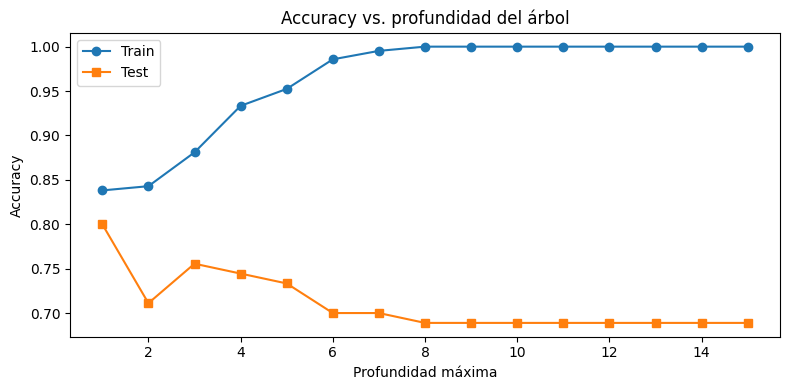

In [4]:
profundidades = range(1, 16)
acc_train = []
acc_test  = []

for d in profundidades:
    arbol = DecisionTreeClassifier(max_depth=d, random_state=42)  # TU CÓDIGO ACÁ
    arbol.fit(X_train, y_train)                                              # TU CÓDIGO ACÁ
    acc_train.append(accuracy_score(y_train, arbol.predict(X_train)))        # TU CÓDIGO ACÁ
    acc_test.append(accuracy_score(y_test, arbol.predict(X_test)))         # TU CÓDIGO ACÁ

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(profundidades, acc_train, marker='o', label='Train')
ax.plot(profundidades, acc_test,  marker='s', label='Test')
ax.set_xlabel('Profundidad máxima')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy vs. profundidad del árbol')
ax.legend()
plt.tight_layout()
plt.show()

**Ejercicio 3.2** — Mirá la curva. ¿A partir de qué profundidad el modelo empieza a sobreajustar? ¿Cómo lo identificás en el gráfico?

Notamos que en la profundidad 3, el accuracy de test alcanza un máximo y la diferencia con el accuracy de train no es tan grande. A partir de la profundidad 4, el accuracy de test empieza a bajar mientras que la de train sube, por lo tanto vemos que el modelo está sobreajustando. 

**Ejercicio 3.3** — Usá validación cruzada (CV) de 5 folds estratificada para elegir la mejor profundidad. Completá el código.

In [5]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # TU CÓDIGO ACÁ
cv_scores = []

for d in profundidades:
    arbol = DecisionTreeClassifier(max_depth=16, random_state=42)  # TU CÓDIGO ACÁ
    scores = cross_val_score(arbol, X_train, y_train, cv=cv)         # TU CÓDIGO ACÁ
    cv_scores.append(scores.mean())

mejor_d = list(profundidades)[np.argmax(cv_scores)]
print(f'Mejor profundidad por CV: {mejor_d}')
print(f'Accuracy CV promedio: {max(cv_scores):.3f}')

Mejor profundidad por CV: 1
Accuracy CV promedio: 0.829


**Ejercicio 3.4** — Visualizá el árbol final con la profundidad elegida.

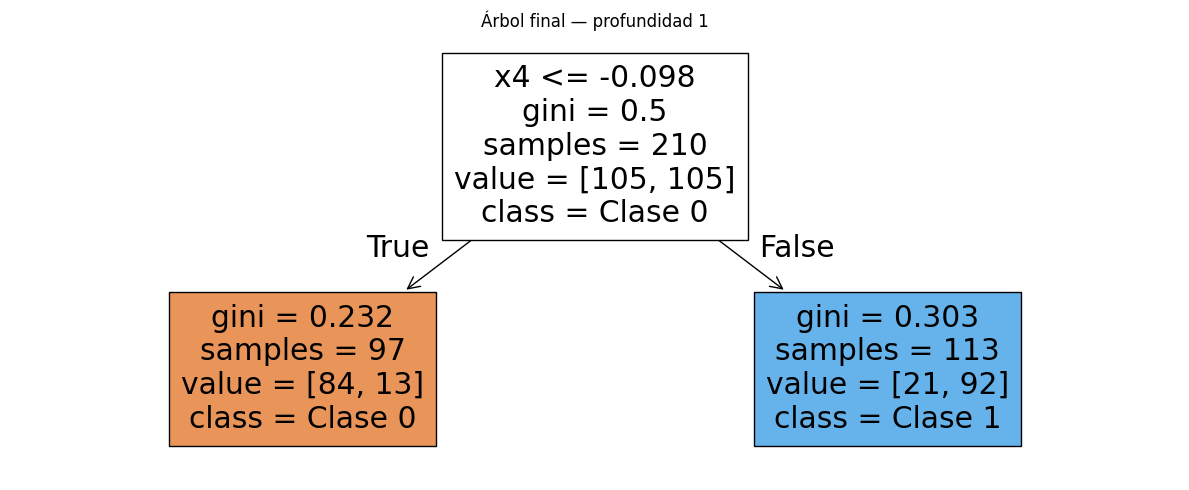

In [6]:
arbol_final = DecisionTreeClassifier(max_depth=mejor_d, random_state=42)
arbol_final.fit(X_train, y_train)  # TU CÓDIGO ACÁ

fig, ax = plt.subplots(figsize=(12, 5))
plot_tree(
    arbol_final,                            # TU CÓDIGO ACÁ
    filled=True,
    feature_names=[f'x{i}' for i in range(X.shape[1])],
    class_names=['Clase 0', 'Clase 1'],
    ax=ax
)
ax.set_title(f'Árbol final — profundidad {mejor_d}')
plt.tight_layout()
plt.show()

---

## Preguntas de reflexión final

1. ¿Qué ventaja tiene la Entropía sobre Gini como criterio de split? ¿Y qué desventaja?
2. Un árbol sin restricción de profundidad sobre el conjunto de entrenamiento tiene accuracy = 1.0. ¿Es un modelo bueno? Justificá.
3. ¿Por qué se usa CV estratificada en lugar de CV simple cuando las clases están desbalanceadas?

1. **Entropía vs Gini (ventaja y desventaja)**  
La Entropía suele ser un poco m?s sensible cuando las probabilidades de clase est?n cerca de los extremos (nodos casi puros), por eso puede discriminar mejor ciertos splits finos. La contracara es computacional: requiere logaritmos y suele ser m?s costosa que Gini, que usa una f?rmula m?s simple. En la pr?ctica, ambos criterios suelen llevar a ?rboles parecidos y las diferencias de performance final tienden a ser chicas.

2. **Accuracy de train = 1.0, ¿modelo bueno?**  
No necesariamente: suele ser señal de sobreajuste. Un árbol muy profundo puede memorizar el set de entrenamiento (incluyendo ruido) y aun así generalizar mal. Lo importante es el desempeño en validación/test. En nuestros ejercicios se ve que al crecer la profundidad, train sigue subiendo pero test deja de mejorar (o cae), que es el patr?n t?pico de overfitting.

3. **Por qué CV estratificada con clases desbalanceadas**  
Con KFold simple, algunos folds pueden quedar con poca (o nula) presencia de la clase minoritaria, y eso vuelve inestable la evaluación. StratifiedKFold conserva la proporción de clases en cada pliegue, haciendo que cada partici?n sea m?s representativa del problema real. Por eso la comparaci?n entre profundidades/hiperpar?metros resulta m?s confiable.